# Performance Analysis - Study 1

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
from scipy import stats
import seaborn as sns
import matplotlib as mpl

## Loading the data

In [ ]:
df = pd.read_csv('./processed/ageRisk_long.csv', index_col=0)

## Fetching performance data & calculating performance measures

In [ ]:
benchmark_ticker = 'VT'
start_date = '2023-07-01'
end_date = '2025-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

# Fetches the annualized risk free rate from FRED 
def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()

In [ ]:
# Fetches pricing data for assets from Yahoo Finance
def get_market_data(tickers):
    for ticker in tickers:
        if ticker in market_data:
            return
        else:
            try:
                prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
                market_data[ticker] = prices
            except:
                market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                               index=market_data[next(iter(market_data))].index)

def calc_performance_metrics(portfolio_returns):
    endpoints = portfolio_returns.resample('M').last().index
    expanding_returns = []
    expanding_volatility = []
    expanding_sharpe_ratios = []
    
    for date in endpoints:
        period_returns = portfolio_returns.loc[:date]
        n_weeks= len(pd.date_range(start=start_date, end=date, freq='W'))

        # Calculate cumulative returns
        cumulative_return = (1 + period_returns).prod() - 1
        
        # Calculate annualized and annualized excess return for Sharpe ratio
        annualized_return = (1 + cumulative_return) ** (52 / n_weeks) - 1
        excess_return = annualized_return - risk_free_rate
        
        # Calculate annualized volatility 
        weekly_returns = (1 + period_returns).resample('W').prod() - 1
        weekly_volatility = weekly_returns.std()
        annualized_volatility = weekly_volatility * np.sqrt(52)

        # Calculate Sharpe ratio
        sharpe_ratio = excess_return / annualized_volatility if annualized_volatility > 0 else np.nan
        
        expanding_returns.append(cumulative_return)
        expanding_volatility.append(annualized_volatility)
        expanding_sharpe_ratios.append(sharpe_ratio)

    return expanding_returns, expanding_volatility, expanding_sharpe_ratios, endpoints

    

def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())

    portfolio_df = []  # For time-series data
    grouped = df.groupby(group_cols)

    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
        
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # Calculate daily portfolio returns
        daily_returns = prices_df.pct_change().fillna(0)
        portfolio_returns = (daily_returns * weights.values).sum(axis=1)

        expanding_returns, expanding_volatility, expanding_sharpe_ratios, endpoints = calc_performance_metrics(portfolio_returns)       
          
        df_temp = pd.DataFrame({
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'iteration': name[3],
            'date': endpoints,
            'portfolio_cumulative_return': expanding_returns,
            'portfolio_std_dev': expanding_volatility,
            'sharpe_ratio': expanding_sharpe_ratios,
        })
        portfolio_df.append(df_temp)

    return pd.concat(portfolio_df, ignore_index=True)


# Get time-series data and final summary values
group_cols = ['ai', 'age', 'risk-taking', 'iteration']    
portfolio_time_series_df = get_portfolio_data(df, group_cols)

# Save performance data
portfolio_time_series_df.to_csv('./processed/performance_weekly.csv')


In [ ]:
def get_benchmark_performance(ticker):
    get_market_data([ticker])
    prices_df = pd.DataFrame()
    prices_df[ticker]  = market_data[ticker]
    prices_df = prices_df.ffill().bfill().fillna(1)
    
    daily_returns = prices_df.pct_change().fillna(0)
    benchmark_returns = daily_returns.sum(axis=1)

    expanding_returns, expanding_volatility, expanding_sharpe_ratios, endpoints = calc_performance_metrics(benchmark_returns)

    df_tmp = pd.DataFrame({
            'ai': 'Benchmark (VT)',
            'date': endpoints,
            'portfolio_cumulative_return': expanding_returns,
            'portfolio_std_dev': expanding_volatility,
            'sharpe_ratio': expanding_sharpe_ratios,
        })

    return df_tmp

benchmark_timeseries = get_benchmark_performance(benchmark_ticker)
benchmark_timeseries.to_csv('./processed/performance_benchmark_weekly.csv')

## Analysis

In [2]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.sans-serif'] = 'Arial'

In [3]:
portfolios_timeseries = pd.read_csv('./processed/performance_weekly.csv', index_col=0)
benchmark_timeseries = pd.read_csv('./processed/performance_benchmark_weekly.csv', index_col=0)

portfolios_timeseries['date'] = pd.to_datetime(portfolios_timeseries['date'])
benchmark_timeseries['date'] = pd.to_datetime(benchmark_timeseries['date'])

portfolios_timeseries['portfolio_cumulative_return'] = portfolios_timeseries['portfolio_cumulative_return'] * 100
benchmark_timeseries['portfolio_cumulative_return'] = benchmark_timeseries['portfolio_cumulative_return'] * 100

portfolios_timeseries['risk-taking'] = portfolios_timeseries['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolios_timeseries['risk-taking'] = pd.Categorical(portfolios_timeseries['risk-taking'], categories=['low', 'medium', 'high'], ordered=True)
portfolios_timeseries.sort_values(by='risk-taking', inplace=True)


In [4]:
def plot_timeline(raw, raw_benchmark, column, ylab, groups, filename):
    grouped = raw.groupby(groups, observed=False)[column].mean().reset_index()
    grouped = grouped.sort_values(by='date')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grouped, x='date', y=column, hue='ai', marker='o', linewidth=2.5)

    plt.plot(raw_benchmark['date'], 
             raw_benchmark[column], 
             label='Benchmark (VT)', 
             color='black', 
             linestyle='--', 
             linewidth=2.5, 
             marker='o',
             alpha=.75
            )
    
    plt.xlabel('Date')
    plt.ylabel(ylab)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.legend(title='')
    plt.grid(True, alpha=.3)
    plt.tight_layout()

    plt.savefig(f'./figures/{filename}.png')
    plt.show()

def plot_timeline_detailed(raw, raw_benchmark, column, ylab, group, group_lab, filename):
    groups = ['date', 'ai', group]
    grouped = raw.groupby(groups, observed=False)[column].mean().reset_index()
    grouped = grouped.sort_values(by=groups)
    
    unique_ais = grouped['ai'].unique()
    base_colors = sns.color_palette("deep", n_colors=len(unique_ais))
    
    color_dict = {}
    for i, ai in enumerate(unique_ais):
        ai_data = grouped[grouped['ai'] == ai]
        group_groups = ai_data[group].unique()
        base_color = base_colors[i]
        
        for j, elem in enumerate(group_groups):
            color_dict[f"{ai}_{elem}"] = sns.set_hls_values(
                base_color, 
                l=max(0.3, 0.65 - j * 0.15)  # Adjust lightness
            )
    
    plt.figure(figsize=(12, 6))
    
    # Plot lines for each AI-group combination
    for ai in unique_ais:
        ai_data = grouped[grouped['ai'] == ai]
        for elem in ai_data[group].unique():
            data = ai_data[ai_data[group] == elem]
            plt.plot(data['date'], 
                    data[column],
                    label=f"{ai} / {elem}",
                    color=color_dict[f"{ai}_{elem}"],
                    marker="o",
                    linewidth=2.5)
    
    # Add benchmark
    plt.plot(raw_benchmark['date'], 
             raw_benchmark[column], 
             label='Benchmark (VT)', 
             color='black', 
             linestyle='--', 
             linewidth=2.5, 
             marker='o',
             alpha=.6)
    
    plt.xlabel('Date')
    plt.ylabel(ylab)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.legend(title=f'LLM / {group_lab}', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(f'./figures/{filename}.png')
    plt.show()

### Returns

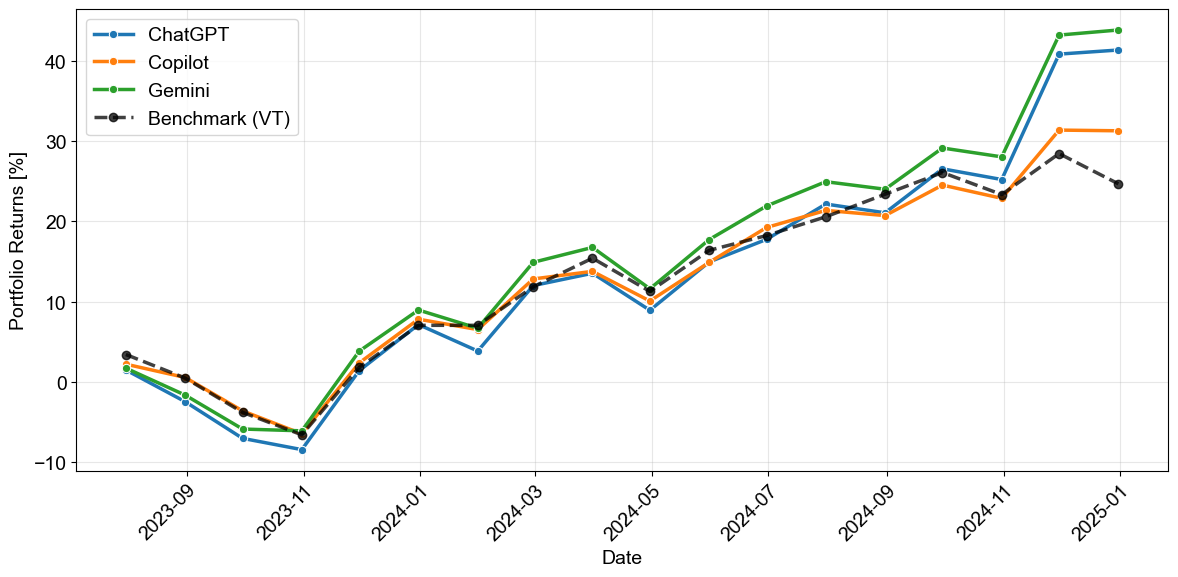

In [5]:
plot_timeline(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'portfolio_cumulative_return', 
    'Portfolio Returns [%]', 
    ['ai', 'date'], 
    'performance_returns')

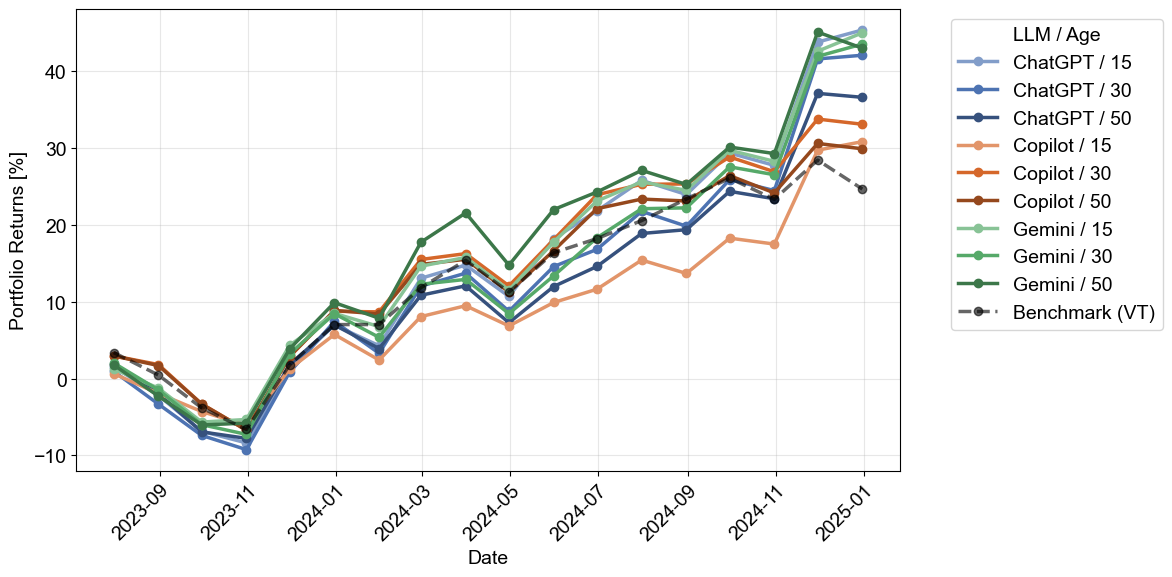

In [6]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'portfolio_cumulative_return',
    'Portfolio Returns [%]',
    'age',
    'Age',
    'performance_return_age'
)

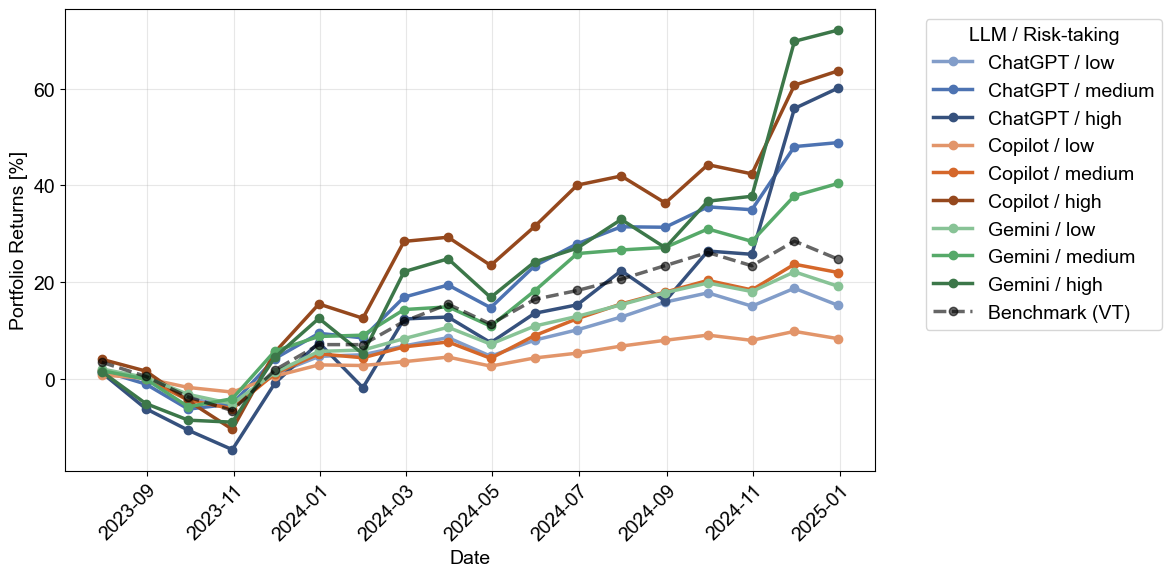

In [7]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'portfolio_cumulative_return',
    'Portfolio Returns [%]',
    'risk-taking',
    'Risk-taking',
    'performance_return_risk'
)

### Sharpe Ratio

In [8]:
print(portfolios_timeseries.shape)
print(benchmark_timeseries.shape)

(4860, 8)
(18, 5)


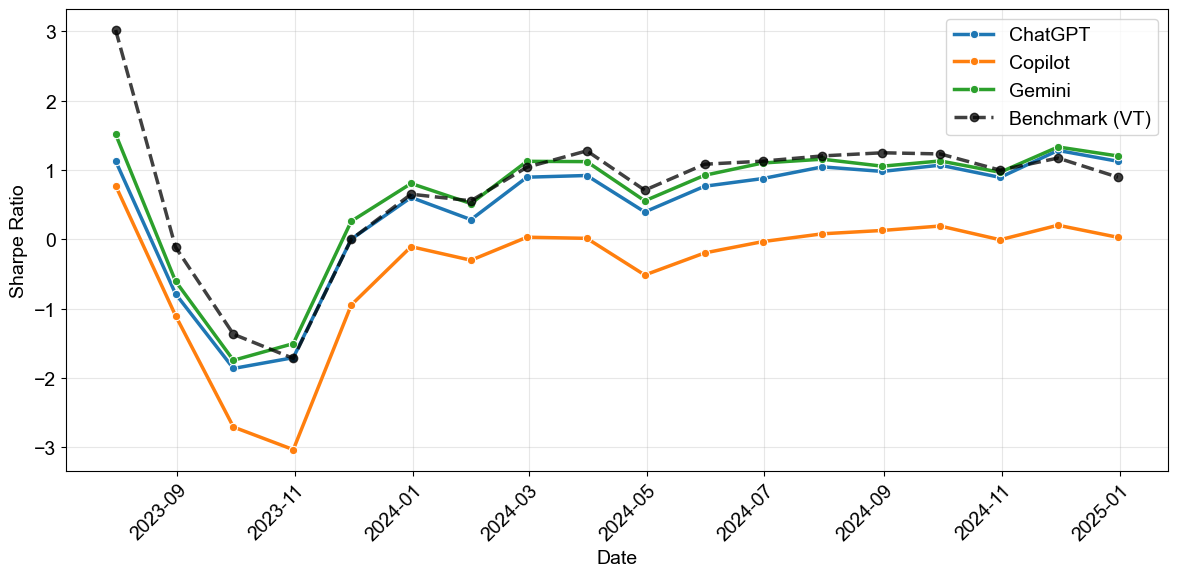

In [9]:
plot_timeline(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'sharpe_ratio', 
    'Sharpe Ratio', 
    ['ai', 'date'], 
    'performance_sharpe')

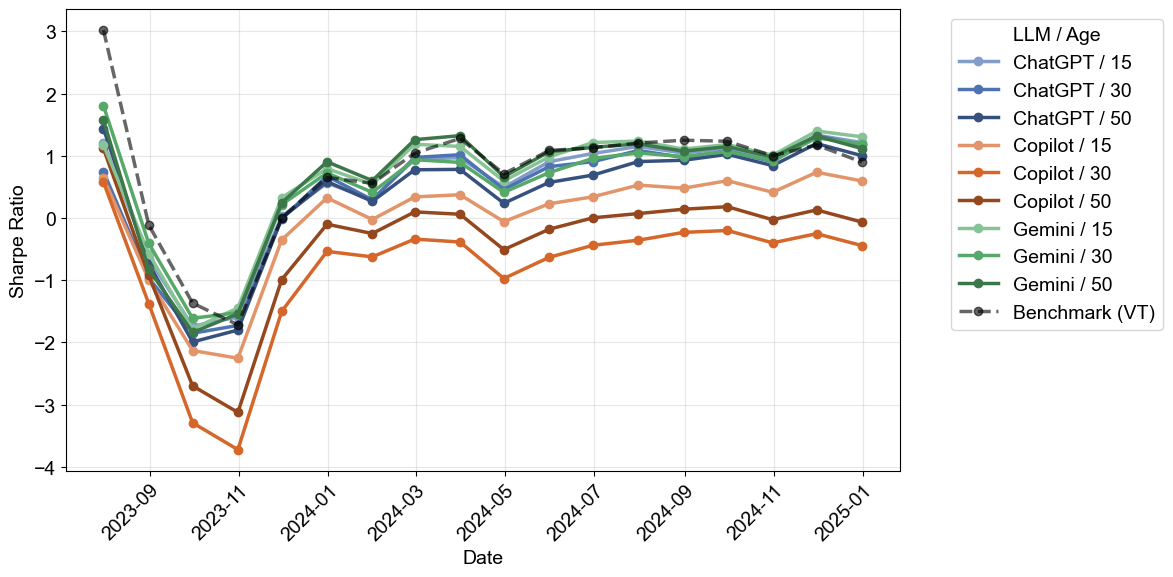

In [10]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'sharpe_ratio',
    'Sharpe Ratio',
    'age',
    'Age',
    'performance_sharpe_age'
)

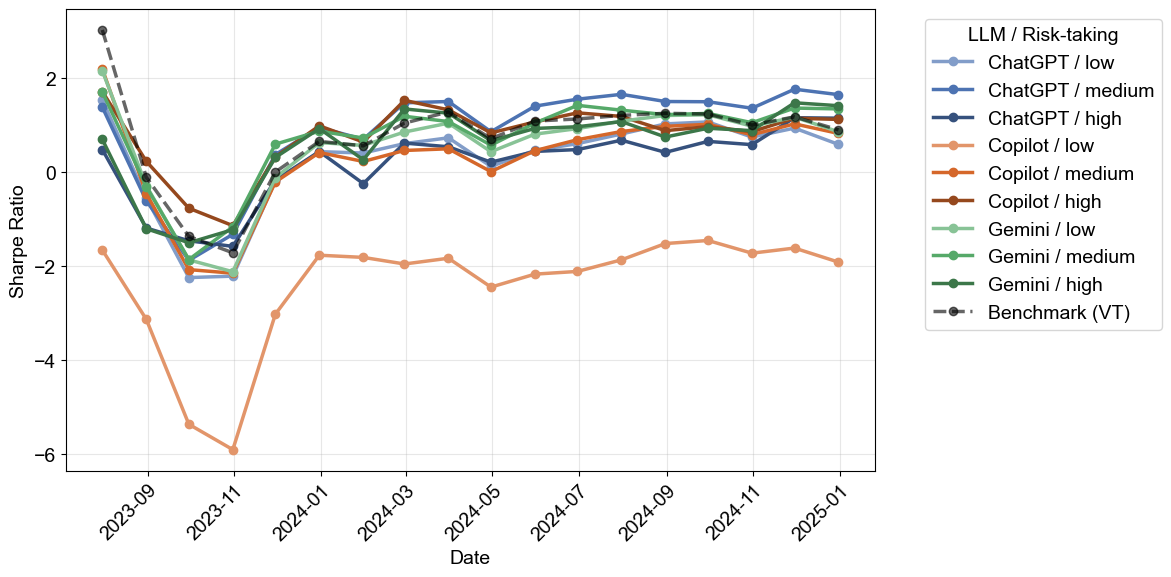

In [11]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'sharpe_ratio',
    'Sharpe Ratio',
    'risk-taking',
    'Risk-taking',
    'performance_sharpe_risk'
)

## Linear Mixed Model

In [12]:
benchmark_rows = benchmark_timeseries.copy()
benchmark_rows['ai'] = 'Benchmark'
benchmark_rows['risk-taking'] = 'Benchmark'  
benchmark_rows['age'] = 'Benchmark'
benchmark_rows['iteration'] = 'Benchmark'

print(portfolios_timeseries.shape)
print(benchmark_rows.shape)
df_comb = pd.concat([portfolios_timeseries, benchmark_rows], ignore_index=True).dropna()
df_comb.rename(columns={'risk-taking': 'risk_taking'}, inplace=True)
print(df_comb.shape)

(4860, 8)
(18, 8)
(4860, 8)


In [26]:
def calculate_mixed_model(df, column, group1, group2=None):
    if group2:
        df['label'] = df.apply(lambda row: f'({row[group1]}, {row[group2]})', axis=1)
    else:
        df['label'] = df[group1]

    lmm = smf.mixedlm(f'{column} ~ label + date', data=df, groups=df['date']).fit()
    print(lmm.summary())

### Returns

In [27]:
calculate_mixed_model(df_comb, 'portfolio_cumulative_return', 'ai')

                          Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      portfolio_cumulative_return
No. Observations:       4860         Method:                  REML                       
No. Groups:             18           Scale:                   162.9465                   
Min. group size:        270          Log-Likelihood:          -19248.4447                
Max. group size:        270          Converged:               Yes                        
Mean group size:        270.0                                                            
-----------------------------------------------------------------------------------------
                                          Coef.    Std.Err.     z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                  0.464       13.137  0.035 0.972 -25.284 26.211
label[T.ChatGPT]                    

In [15]:
calculate_mixed_model(df_comb, 'portfolio_cumulative_return', 'ai', 'risk_taking')

                          Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      portfolio_cumulative_return
No. Observations:       4860         Method:                  REML                       
No. Groups:             18           Scale:                   118.0868                   
Min. group size:        270          Log-Likelihood:          -18463.7474                
Max. group size:        270          Converged:               Yes                        
Mean group size:        270.0                                                            
-----------------------------------------------------------------------------------------
                                          Coef.    Std.Err.     z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                  0.464       11.183  0.041 0.967 -21.455 22.382
label[T.(ChatGPT, high)]            

In [16]:
calculate_mixed_model(df_comb, 'portfolio_cumulative_return', 'ai', 'age')

                          Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      portfolio_cumulative_return
No. Observations:       4860         Method:                  REML                       
No. Groups:             18           Scale:                   159.7598                   
Min. group size:        270          Log-Likelihood:          -19194.1393                
Max. group size:        270          Converged:               Yes                        
Mean group size:        270.0                                                            
-----------------------------------------------------------------------------------------
                                          Coef.    Std.Err.     z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                  0.464       13.007  0.036 0.972 -25.030 25.958
label[T.(ChatGPT, 15)]              

### Sharpe Ratio

In [17]:
calculate_mixed_model(df_comb, 'sharpe_ratio', 'ai')

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          sharpe_ratio
No. Observations:           4860             Method:                      REML        
No. Groups:                 18               Scale:                       3.3804      
Min. group size:            270              Log-Likelihood:              -9871.8600  
Max. group size:            270              Converged:                   Yes         
Mean group size:            270.0                                                     
--------------------------------------------------------------------------------------
                                         Coef.    Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 1.658       1.892  0.877 0.381 -2.050  5.367
label[T.ChatGPT]                         -0.283       0.436 -0.650 0

In [18]:
calculate_mixed_model(df_comb, 'sharpe_ratio', 'ai', 'risk_taking')

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          sharpe_ratio
No. Observations:           4860             Method:                      REML        
No. Groups:                 18               Scale:                       2.7024      
Min. group size:            270              Log-Likelihood:              -9335.9516  
Max. group size:            270              Converged:                   Yes         
Mean group size:            270.0                                                     
--------------------------------------------------------------------------------------
                                         Coef.    Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 1.658       1.692  0.980 0.327 -1.657  4.974
label[T.(ChatGPT, high)]                 -0.548       0.394 -1.391 0

In [19]:
calculate_mixed_model(df_comb, 'sharpe_ratio', 'ai', 'age')

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          sharpe_ratio
No. Observations:           4860             Method:                      REML        
No. Groups:                 18               Scale:                       3.3446      
Min. group size:            270              Log-Likelihood:              -9851.1964  
Max. group size:            270              Converged:                   Yes         
Mean group size:            270.0                                                     
--------------------------------------------------------------------------------------
                                         Coef.    Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 1.658       1.882  0.881 0.378 -2.030  5.347
label[T.(ChatGPT, 15)]                   -0.211       0.438 -0.481 0

## ANOVAs & t-tests (single date)

### Return

In [20]:
min_date = df_comb['date'].min()
max_date = df_comb['date'].max()
df_time = portfolios_timeseries[(portfolios_timeseries['date'] == min_date) | (portfolios_timeseries['date'] == max_date)]
benchmark_last = benchmark_timeseries[benchmark_timeseries['date'] == max_date].iloc[0]

In [21]:
def show_ttest(raw, column, groups, benchmark):
    for (llm, timepoint), group_data in raw.groupby(groups):
        benchmark_val = benchmark[benchmark['date'] == timepoint].iloc[0][column]
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        d = group_values.mean() - benchmark_val
        print(f'group: ({llm}, {timepoint}) got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 2)} d: {round(d, 2)}')

def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def calc_stats(raw, column, benchmark, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

def print_stats(raw, column, benchmark, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)

In [22]:
print_stats(df_time, 'portfolio_cumulative_return', benchmark_timeseries, 'ai', 'date')

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_10035/2996237200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)


                sum_sq     df           F        PR(>F)
label     193581.56373    5.0  114.812459  2.804818e-82
Residual  180072.01653  534.0         NaN           NaN
                         Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
            group1                         group2             meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------------------------
(ChatGPT, 2023-07-31 00:00:00) (ChatGPT, 2024-12-31 00:00:00)  39.9226    0.0  32.0932   47.752   True
(ChatGPT, 2023-07-31 00:00:00) (Copilot, 2023-07-31 00:00:00)   0.7263 0.9998  -7.1031   8.5557  False
(ChatGPT, 2023-07-31 00:00:00) (Copilot, 2024-12-31 00:00:00)  29.8436    0.0  22.0143   37.673   True
(ChatGPT, 2023-07-31 00:00:00)  (Gemini, 2023-07-31 00:00:00)   0.2318    1.0  -7.5975   8.0612  False
(ChatGPT, 2023-07-31 00:00:00)  (Gemini, 2024-12-31 00:00:00)  42.4204    0.0   34.591  50.2498   True
(ChatGPT

### Sharpe Ratio

In [23]:
print_stats(df_time.dropna(), 'sharpe_ratio', benchmark_timeseries, 'ai', 'date')

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_10035/2996237200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)


               sum_sq     df         F    PR(>F)
label      118.313655    5.0  5.392937  0.000075
Residual  2334.270367  532.0       NaN       NaN
                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                         
            group1                         group2             meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------
(ChatGPT, 2023-07-31 00:00:00) (ChatGPT, 2024-12-31 00:00:00)  -0.0038    1.0 -0.8969  0.8893  False
(ChatGPT, 2023-07-31 00:00:00) (Copilot, 2023-07-31 00:00:00)  -0.3552 0.8669 -1.2508  0.5404  False
(ChatGPT, 2023-07-31 00:00:00) (Copilot, 2024-12-31 00:00:00)  -1.1005 0.0063 -1.9961 -0.2049   True
(ChatGPT, 2023-07-31 00:00:00)  (Gemini, 2023-07-31 00:00:00)    0.386  0.819 -0.5071  1.2791  False
(ChatGPT, 2023-07-31 00:00:00)  (Gemini, 2024-12-31 00:00:00)   0.0729 0.9999 -0.8202   0.966  False
(ChatGPT, 2024-12-31 00:00:00) (Copilot, 2023

In [ ]:
portfolio_df = pd.read_csv('./processed/performance_features.csv', index_col=0)
portfolio_df['risk-taking'] = portfolio_df['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolio_df['portfolio_std_dev'] *= 100 # in %
portfolio_df['portfolio_return'] *= 100 # in %

In [ ]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk-taking':'Risk Tendency'}

# Calculates the benchmark return, benchmark volatility, and benchmark sharpe ratio 
def fetch_benchmark_data(ticker):
    prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
    cumulative_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    returns_df = prices.pct_change()
    std_dev = returns_df.std()
    sharpe = (cumulative_return - risk_free_rate) / std_dev
    return cumulative_return, std_dev, sharpe

# Calculates and prints an ANOVA and TukeyHSD results
def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
        
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

# Calculates and prints t-tests between samples and a fixed benchmark value
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups, observed=False):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')
    
# Prints a mean plot relative to a fixed benchmark value
def show_mean_errplot(raw, column, label, benchmark, benchmark_label, group1, group2=None):
    show_anova(raw, column, group1, group2)

    if group1 == 'risk-taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
    
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups, observed=False)[column]
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()

    standard_errors = std_devs / np.sqrt(sample_sizes)

    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(5, 4), color=colors, zorder=2)
    ax.axhline(y=benchmark, color='black', linestyle='--', zorder=4)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    ax.set_ylabel(label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    group1 = label_dict.get(group1, group1)
    ax.set_xlabel(group1)
    ax.grid(True, zorder=1)
    
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2, bbox_to_anchor=(1.02, 1), loc='upper left')
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/performance/{group1}{group2_label}-{label}.png', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    

In [ ]:
benchmark_return, benchmark_std, benchmark_sharpe = fetch_benchmark_data('VT')
benchmark_return *= 100 # in %
benchmark_std *= 100 # in %

### Portfolio Return

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'ai')

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]',  benchmark_return, 'Benchmark (VT)', 'risk-taking')

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'age')

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'ai', 'risk-taking')

### Portfolio Volatility

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'ai')

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'risk-taking')

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'age')

In [ ]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'ai', 'risk-taking')

### Sharpe

In [ ]:
print(portfolio_df.shape)
sharpe_df = portfolio_df.copy()
sharpe_df = sharpe_df.dropna()
print(sharpe_df.shape)

In [ ]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'ai')

In [ ]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'risk-taking')

In [ ]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'age')

In [ ]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'ai', 'risk-taking')